In [8]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\Kev\Downloads\demographic_infused_philly_c.parquet")
sample_df = df[['review_id', 'text', 'stars_rev', 'business_id', 'date']].dropna().sample(n=300, random_state=42)
sample_df.to_csv(r"C:\Users\Kev\Downloads\sentiment_manual_labeling_300.csv", index=False)




In [9]:
!pip install nltk textblob


   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 7.7 MB/s eta 0:00:00


In [10]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Kev\AppData\Roaming\nltk_data...


True

In [19]:
df = pd.read_csv(r"C:\Users\Kev\Downloads\sentiment_fully_reviewed_300.csv")
df = df[['text', 'human_label']].dropna()


In [21]:
# === STEP 2: Create a Balanced Sample (50 per class) using pd.concat ===
positive_samples = df[df['human_label'] == 'Positive'].sample(50, random_state=1)
neutral_samples = df[df['human_label'] == 'Neutral'].sample(50, random_state=1)
negative_samples = df[df['human_label'] == 'Negative'].sample(50, random_state=1)

# Combine them into one balanced DataFrame
balanced_df = pd.concat([positive_samples, neutral_samples, negative_samples], ignore_index=True)


In [22]:
sia = SentimentIntensityAnalyzer()

def vader_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

def textblob_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.2:
        return 'Positive'
    elif polarity < -0.2:
        return 'Negative'
    else:
        return 'Neutral'


In [24]:
balanced_df['vader_score'] = balanced_df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
balanced_df['vader_prediction'] = balanced_df['vader_score'].apply(vader_sentiment)

balanced_df['textblob_prediction'] = balanced_df['text'].apply(textblob_sentiment)



In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- Classification Report: {model_name} ---")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred, labels=['Positive', 'Neutral', 'Negative'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Neutral', 'Negative'],
                yticklabels=['Positive', 'Neutral', 'Negative'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



--- Classification Report: VADER (Tuned ±0.1) ---
              precision    recall  f1-score   support

    Negative       0.75      0.42      0.54        50
     Neutral       0.00      0.00      0.00        50
    Positive       0.41      0.96      0.57        50

    accuracy                           0.46       150
   macro avg       0.39      0.46      0.37       150
weighted avg       0.39      0.46      0.37       150



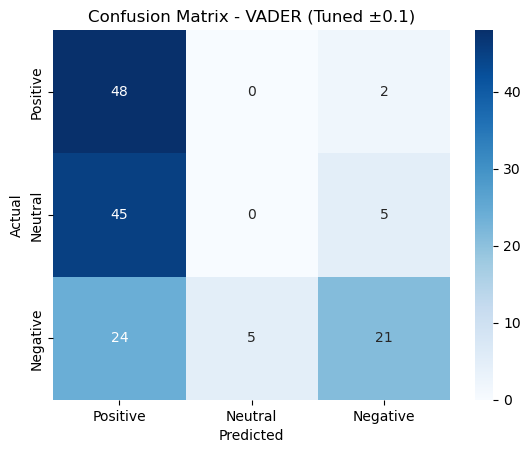


--- Classification Report: TextBlob (Tuned ±0.2) ---
              precision    recall  f1-score   support

    Negative       0.80      0.08      0.15        50
     Neutral       0.35      0.58      0.44        50
    Positive       0.58      0.72      0.64        50

    accuracy                           0.46       150
   macro avg       0.58      0.46      0.41       150
weighted avg       0.58      0.46      0.41       150



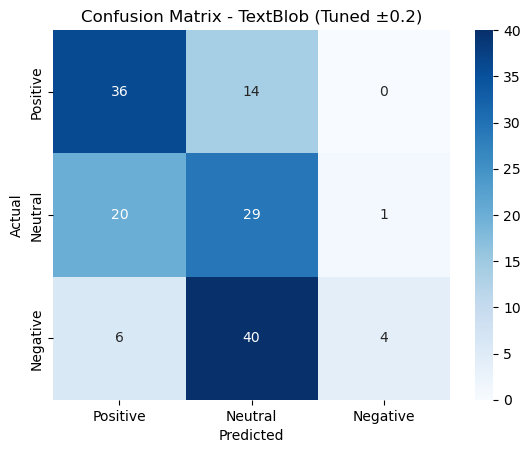

In [26]:
evaluate_model(balanced_df['human_label'], balanced_df['vader_prediction'], 'VADER (Tuned ±0.1)')
evaluate_model(balanced_df['human_label'], balanced_df['textblob_prediction'], 'TextBlob (Tuned ±0.2)')